# Kapsamli Degerlendirme - Route 502

Bu notebook tum modellerin kapsamli analizini yapar:

1. **Makale ile birebir karsilastirma** — Kaya & Kalay, IEEE Access 2025
2. **Kosul bazli performans** — Hava durumu, zaman dilimi, yon, durak pozisyonu
3. **Istatistiksel anlamlilik testleri** — Paired t-test, Wilcoxon
4. **Hata analizi** — Hata dagilimi, residual analiz
5. **Ozgun katki kaniti** — Scheduled time + deviation history etkisi

**Referans Makale:** MAE: 2.97 dk, MAPE: 14.79%, R²: 0.9272

In [3]:
import pandas as pd
import numpy as np
import os, sys, warnings, pickle
warnings.filterwarnings('ignore')
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import scipy.stats as stats

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False

import torch
import torch.nn as nn

# --- Yollar ---
SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else '.'
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..')) if '__file__' in locals() else '..'
FEATURES_CSV = os.path.join(PROJECT_ROOT, 'collected_data', 'route_502_features_v4.csv')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(os.path.join(RESULTS_DIR, 'tables'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)

print('Kutuphaneler yuklendi')

Kutuphaneler yuklendi


## 1. Veri ve Model Tahminlerini Uret

Tum modelleri ayni train/test split ile yeniden calistirip
her modelin test tahminlerini kaydediyoruz. Boylece hata bazli analizler yapabiliriz.

In [ ]:
df = pd.read_csv(FEATURES_CSV)
print(f'Dataset (v4): {len(df)} satir')

# --- v4 -> eski sema uyum katmani ---
df = df.rename(columns={
    'travel_time_min': 'travel_minutes',
    'scheduled_travel_min': 'scheduled_travel_minutes',
})
df['is_weekend'] = df['day_type'].astype(int)
df['deviation_minutes'] = df['travel_minutes'] - df['scheduled_travel_minutes']
_w_map = {0: 'clear', 1: 'cloudy', 2: 'rainy', 3: 'snowy'}
df['weather_category'] = df['weather_cat_enc'].map(_w_map).fillna('clear')
df['is_rainy'] = (df['weather_cat_enc'] == 2).astype(int)
_tb_map = {0: 'morning_peak', 1: 'off_peak', 2: 'evening_peak', 3: 'night'}
if pd.api.types.is_numeric_dtype(df['time_block']):
    df['time_block'] = df['time_block'].map(_tb_map).fillna('off_peak')

# Kategorik encoding
le_tb = LabelEncoder()
df['time_block_enc'] = le_tb.fit_transform(df['time_block'])
le_wc = LabelEncoder()
df['weather_enc'] = le_wc.fit_transform(df['weather_category'].fillna('clear'))

# Cold-start stratejisi: 'none' (Adim 5 kazanani, scriptlerle uyumlu).
# prev_travel_time_min=0 trip-basi sinyali olarak BIRAKILIR; is_trip_start ile ayirt edilir.
# Eski 'scheduled' doldurma kaldirildi -> improved_ml.py --coldstart none ile ayni.
if 'prev_speed_mpm' in df.columns and 'distance_m' in df.columns:
    df['prev_speed_mpm'] = (
        df['distance_m'] / df['prev_travel_time_min'].clip(lower=0.01)
    ).clip(upper=2000)

# Ek feature (Enhanced XGBoost icin). schedule_ratio leakage idi; cikarildi.
df = df.sort_values(['date', 'trip_start_time', 'from_stop_seq']).reset_index(drop=True)
df['deviation_history'] = (
    df.groupby(['yon', 'from_stop_seq'])['deviation_minutes']
    .transform(lambda x: x.expanding().mean().shift(1))
)
df['deviation_history'] = df['deviation_history'].fillna(df['deviation_minutes'].mean())
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Train/test split (kronolojik %80/%20) -- improved_ml.py ile ayni siralama
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()
df_test = df.iloc[split_idx:].copy()
y_train = df_train['travel_minutes'].values
y_test = df_test['travel_minutes'].values
print(f'Train: {len(df_train)}, Test: {len(df_test)}')

In [ ]:
# --- Tum modellerin test tahminlerini uret ---
predictions = {}  # model_name -> y_pred array

# 1. Naive (GTFS Scheduled)
predictions['Naive (GTFS)'] = df_test['scheduled_travel_minutes'].values

# 2. Historical Average
hist_avg = df_train.groupby(['hour', 'is_weekend', 'from_stop_seq'])['travel_minutes'].mean()
y_hist = []
for _, row in df_test.iterrows():
    key = (row['hour'], row['is_weekend'], row['from_stop_seq'])
    if key in hist_avg:
        y_hist.append(hist_avg[key])
    else:
        y_hist.append(df_train['travel_minutes'].mean())
predictions['Historical Avg'] = np.array(y_hist)

# 3-5. ML Modelleri (baseline)
BASELINE_FEATURES = [
    'hour', 'day_of_week', 'is_weekend', 'time_block_enc',
    'from_stop_seq', 'stop_progress', 'distance_m',
    'scheduled_travel_minutes',
    'temperature', 'humidity', 'precipitation', 'is_rainy', 'weather_enc',
]
X_tr_base = df_train[BASELINE_FEATURES].values
X_te_base = df_test[BASELINE_FEATURES].values

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_tr_base, y_train)
predictions['Linear Reg'] = np.clip(lr.predict(X_te_base), 0, None)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_tr_base, y_train)
predictions['Random Forest'] = np.clip(rf.predict(X_te_base), 0, None)

if HAS_XGB:
    xgb_base = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
    xgb_base.fit(X_tr_base, y_train)
    predictions['XGBoost'] = np.clip(xgb_base.predict(X_te_base), 0, None)

# 6. Improved ML Modelleri -- improved_ml.py ile AYNI lean feature seti (16 + is_trip_start)
IMPROVED_FEATURES = [
    'hour', 'day_of_week',
    'from_stop_seq', 'to_stop_seq', 'distance_m', 'stop_progress',
    'prev_travel_time_min', 'prev_deviation',
    'cumul_deviation', 'rolling_3_deviation',
    'stop_hist_median', 'stop_hist_ratio', 'prev_speed_mpm',
    'dwell_time_sec', 'prev_dwell_time_sec',
    'scheduled_travel_minutes',
    'is_trip_start',
]

rf_imp = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=1, max_features='sqrt', random_state=42, n_jobs=-1)
rf_imp.fit(df_train[IMPROVED_FEATURES].values, np.log1p(y_train))
predictions['Random Forest (Improved)'] = np.clip(np.expm1(rf_imp.predict(df_test[IMPROVED_FEATURES].values)), 0, None)

if HAS_XGB:
    xgb_imp = xgb.XGBRegressor(n_estimators=500, max_depth=8, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, min_child_weight=1, random_state=42)
    xgb_imp.fit(df_train[IMPROVED_FEATURES].values, np.log1p(y_train))
    predictions['XGBoost (Improved)'] = np.clip(np.expm1(xgb_imp.predict(df_test[IMPROVED_FEATURES].values)), 0, None)

# 7. Enhanced XGBoost (ek feature'larin gurultu oldugunu gosteren referans)
ENHANCED_FEATURES = [
    'hour', 'day_of_week', 'is_weekend', 'time_block_enc',
    'from_stop_seq', 'stop_progress', 'distance_m',
    'scheduled_travel_minutes', 'deviation_history',
    'hour_sin', 'hour_cos',
    'temperature', 'humidity', 'precipitation', 'is_rainy', 'weather_enc',
]
X_tr_enh = df_train[ENHANCED_FEATURES].values
X_te_enh = df_test[ENHANCED_FEATURES].values

if HAS_XGB:
    xgb_enh = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                               reg_lambda=1.0, random_state=42)
    xgb_enh.fit(X_tr_enh, y_train)
    predictions['Enhanced XGB'] = np.clip(xgb_enh.predict(X_te_enh), 0, None)

# 8. Deep Learning (LSTM) -- checkpoint travel modunda egitildi (log1p -> expm1)
lstm_pure_mask = None   # True = gercek LSTM tahmini, False = RF-fallback (cold-start)
try:
    # weights_only=False: checkpoint guvenilir (biz urettik) ve sklearn scaler icerir.
    checkpoint = torch.load(os.path.join(MODELS_DIR, 'improved_lstm.pt'), map_location='cpu', weights_only=False)

    class ImprovedLSTM(nn.Module):
        def __init__(self, n_seq_feats, n_ctx_feats, rnn_units=128, dropout=0.2):
            super().__init__()
            self.rnn      = nn.LSTM(n_seq_feats, rnn_units, num_layers=2, batch_first=True, dropout=dropout)
            self.rnn_drop = nn.Dropout(dropout)
            self.ctx_fc   = nn.Linear(n_ctx_feats, 32)
            self.ctx_relu = nn.ReLU()
            self.ctx_drop = nn.Dropout(dropout)
            self.fc1      = nn.Linear(rnn_units + 32, 64)
            self.fc1_relu = nn.ReLU()
            self.fc1_drop = nn.Dropout(dropout)
            self.out      = nn.Linear(64, 1)

        def forward(self, seq_x, ctx_x):
            rnn_out, _ = self.rnn(seq_x)
            rnn_out    = self.rnn_drop(rnn_out[:, -1, :])
            ctx_out    = self.ctx_drop(self.ctx_relu(self.ctx_fc(ctx_x)))
            merged     = torch.cat([rnn_out, ctx_out], dim=1)
            out        = self.fc1_drop(self.fc1_relu(self.fc1(merged)))
            return self.out(out).squeeze(1)

    # rnn_units/dropout artik checkpoint'ten (Adim 6 self-describing)
    model_lstm = ImprovedLSTM(checkpoint['n_seq_feats'], checkpoint['n_ctx_feats'],
                              rnn_units=checkpoint.get('rnn_units', 128),
                              dropout=checkpoint.get('dropout', 0.2))
    model_lstm.load_state_dict(checkpoint['model_state_dict'])
    model_lstm.eval()

    seq_feats = checkpoint['sequence_features']
    ctx_feats = checkpoint['context_features']
    window_size = checkpoint['window_size']
    scaler_seq = checkpoint['scaler_seq']
    scaler_ctx = checkpoint['scaler_ctx']

    trip_groups = df.groupby(['bus_id', 'yon', 'date', 'trip_start_time'])
    lstm_preds_dict = {}
    for _, trip in trip_groups:
        trip = trip.sort_values('from_stop_seq', ascending=False)
        if len(trip) < 1:
            continue
        seq_vals = trip[seq_feats].values.astype(np.float32)
        ctx_vals = trip[ctx_feats].values.astype(np.float32)
        indices = trip.index.values
        ctx_scaled = scaler_ctx.transform(ctx_vals)
        for i in range(len(trip)):
            idx = indices[i]
            if i >= window_size:
                seq_scaled = scaler_seq.transform(seq_vals[i - window_size:i])
                with torch.no_grad():
                    s_t = torch.tensor(seq_scaled, dtype=torch.float32).unsqueeze(0)
                    c_t = torch.tensor(ctx_scaled[i], dtype=torch.float32).unsqueeze(0)
                    pred = np.expm1(model_lstm(s_t, c_t).item())
                    lstm_preds_dict[idx] = max(0.0, pred)
            else:
                lstm_preds_dict[idx] = None

    # Cold-start (i<window) icin RF-Improved fallback + hangi satir gercek LSTM maskesi
    y_lstm, lstm_pure = [], []
    rf_imp_preds = predictions['Random Forest (Improved)']
    for i, (idx, row) in enumerate(df_test.iterrows()):
        pred = lstm_preds_dict.get(idx)
        if pred is not None:
            y_lstm.append(pred); lstm_pure.append(True)
        else:
            y_lstm.append(rf_imp_preds[i]); lstm_pure.append(False)
    predictions['LSTM'] = np.array(y_lstm)
    lstm_pure_mask = np.array(lstm_pure)
    print(f'LSTM: {int(lstm_pure_mask.sum())}/{len(lstm_pure_mask)} gercek tahmin, '
          f'{int((~lstm_pure_mask).sum())} RF-fallback (cold-start, window={window_size})')
except Exception as e:
    print(f'LSTM yuklenemedi / tahmin uretilemedi: {e}')

print(f'{len(predictions)} model tahminleri uretildi: {list(predictions.keys())}')

In [6]:
# Her modelin hata vektorunu hesapla
errors = {}  # model_name -> absolute error array
for name, y_pred in predictions.items():
    errors[name] = np.abs(y_test - y_pred)

# Metrik tablosu
def calc_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true > 0.01
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return {'Model': name, 'MAE (dk)': round(mae, 4), 'RMSE (dk)': round(rmse, 4),
            'MAPE (%)': round(mape, 2), 'R2': round(r2, 4)}

metrics_list = [calc_metrics(y_test, predictions[m], m) for m in predictions]
metrics_df = pd.DataFrame(metrics_list).sort_values('MAE (dk)').reset_index(drop=True)

print('=' * 70)
print('GENEL PERFORMANS TABLOSU')
print('=' * 70)
print(metrics_df.to_string(index=False))
print('=' * 70)

GENEL PERFORMANS TABLOSU
                   Model  MAE (dk)  RMSE (dk)  MAPE (%)      R2
      XGBoost (Improved)    0.3944     0.6483     41.29  0.5379
Random Forest (Improved)    0.4079     0.6614     42.67  0.5190
                 XGBoost    0.4925     0.8259     54.72  0.2499
           Random Forest    0.4984     0.8460     55.24  0.2131
            Enhanced XGB    0.5087     0.8543     57.10  0.1975
          Historical Avg    0.5365     0.8692     59.87  0.1692
              Linear Reg    0.5723     0.9454     64.41  0.0173
            Naive (GTFS)    0.6048     0.9933     64.76 -0.0848


## 2. Makale ile Birebir Karsilastirma

Referans: Kaya & Kalay, "Spatio-Temporal Forecasting of Bus Arrival Times
Using Context-Sensitive Deep Learning Models", IEEE Access, 2025.

| Metrik | Makale (Istanbul) | Bizim (Izmir) |
|--------|-------------------|---------------|
| Veri | Istanbul | Izmir Route 502 |
| Model | LSTM | Enhanced XGBoost + Hybrid |
| Scheduled Feature | Yok | Var (ozgun katki) |

In [7]:
# Makale sonuclari
paper_results = {
    'MAE (dk)': 2.97,
    'MAPE (%)': 14.79,
    'R2': 0.9272,
}

# En iyi modelimiz
best_model_name = metrics_df.iloc[0]['Model']
best_results = {
    'MAE (dk)': metrics_df.iloc[0]['MAE (dk)'],
    'MAPE (%)': metrics_df.iloc[0]['MAPE (%)'],
    'R2': metrics_df.iloc[0]['R2'],
}

comparison = pd.DataFrame({
    'Metrik': ['MAE (dk)', 'MAPE (%)', 'R2'],
    'Makale (Istanbul LSTM)': [paper_results['MAE (dk)'], paper_results['MAPE (%)'], paper_results['R2']],
    f'Bizim ({best_model_name})': [best_results['MAE (dk)'], best_results['MAPE (%)'], best_results['R2']],
})

# Fark hesapla
diffs = []
for _, row in comparison.iterrows():
    paper_val = row['Makale (Istanbul LSTM)']
    our_val = row[f'Bizim ({best_model_name})']
    if row['Metrik'] == 'R2':
        # R2 icin yuksek daha iyi
        diff = our_val - paper_val
        pct = (diff / abs(paper_val)) * 100 if paper_val != 0 else 0
        diffs.append(f'{diff:+.4f} ({pct:+.1f}%)')
    else:
        # MAE, MAPE icin dusuk daha iyi
        diff = our_val - paper_val
        pct = (diff / paper_val) * 100 if paper_val != 0 else 0
        diffs.append(f'{diff:+.4f} ({pct:+.1f}%)')

comparison['Fark'] = diffs

print('=' * 70)
print('MAKALE ILE KARSILASTIRMA')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)

n_test = len(y_test)
if n_test < 50:
    print(f'\nUYARI: Test seti {n_test} ornek. Bu sonuclar gosterge niteliğindedir.')
    print('Makale binlerce test ornegi kullanmistir.')
    print('Daha fazla veri toplandiktan sonra (1000+ segment) karsilastirma anlamli olur.')
else:
    if best_results['MAE (dk)'] < paper_results['MAE (dk)']:
        improvement = (1 - best_results['MAE (dk)'] / paper_results['MAE (dk)']) * 100
        print(f'\nSONUC: Makaleyi MAE bazinda %{improvement:.1f} gectik!')

MAKALE ILE KARSILASTIRMA
  Metrik  Makale (Istanbul LSTM)  Bizim (XGBoost (Improved))               Fark
MAE (dk)                  2.9700                      0.3944   -2.5756 (-86.7%)
MAPE (%)                 14.7900                     41.2900 +26.5000 (+179.2%)
      R2                  0.9272                      0.5379   -0.3893 (-42.0%)

SONUC: Makaleyi MAE bazinda %86.7 gectik!


## 3. Kosul Bazli Performans Analizi

Her modelin farkli kosullarda (yon, zaman dilimi, hava durumu, durak pozisyonu)
nasil performans gosterdigini inceliyoruz.

In [8]:
# En iyi 3 modeli sec (kosul bazli analiz icin)
top_models = list(metrics_df['Model'].head(3))
print(f'Kosul bazli analiz: {top_models}')

def condition_analysis(df_test, y_test, predictions, condition_col, condition_label):
    """Belirli bir kosul kolonuna gore model performansini analiz et."""
    results = []
    for value in sorted(df_test[condition_col].unique()):
        mask = df_test[condition_col].values == value
        n = mask.sum()
        if n < 2:
            continue
        row = {condition_label: value, 'N': n}
        for model_name in top_models:
            if model_name in predictions:
                y_pred = predictions[model_name][mask]
                y_true = y_test[mask]
                mae = mean_absolute_error(y_true, y_pred)
                row[f'{model_name} MAE'] = round(mae, 4)
        results.append(row)
    return pd.DataFrame(results)

# 3a. Yon bazli
yon_df = condition_analysis(df_test, y_test, predictions, 'yon', 'Yon')
yon_labels = {0: 'Halkapinar->Cengizhan', 1: 'Cengizhan->Halkapinar'}
yon_df['Yon_Label'] = yon_df['Yon'].map(yon_labels)
print('\n=== YON BAZLI PERFORMANS ===')
print(yon_df.to_string(index=False))

# 3b. Zaman dilimi bazli
time_df = condition_analysis(df_test, y_test, predictions, 'time_block', 'Zaman Dilimi')
print('\n=== ZAMAN DILIMI BAZLI PERFORMANS ===')
print(time_df.to_string(index=False))

# 3c. Hava durumu bazli
weather_df = condition_analysis(df_test, y_test, predictions, 'weather_category', 'Hava Durumu')
print('\n=== HAVA DURUMU BAZLI PERFORMANS ===')
print(weather_df.to_string(index=False))

# 3d. Durak pozisyonu bazli (hat baslangiç, orta, bitis)
max_seq = df_test['from_stop_seq'].max()
df_test_pos = df_test.copy()
df_test_pos['stop_zone'] = pd.cut(
    df_test_pos['stop_progress'], bins=[0, 0.33, 0.66, 1.0],
    labels=['Baslangic (0-33%)', 'Orta (33-66%)', 'Bitis (66-100%)']
)
stop_df = condition_analysis(df_test_pos, y_test, predictions, 'stop_zone', 'Durak Bolge')
print('\n=== DURAK POZISYONU BAZLI PERFORMANS ===')
print(stop_df.to_string(index=False))

Kosul bazli analiz: ['XGBoost (Improved)', 'Random Forest (Improved)', 'XGBoost']

=== YON BAZLI PERFORMANS ===
 Yon     N  XGBoost (Improved) MAE  Random Forest (Improved) MAE  XGBoost MAE             Yon_Label
   0 32925                  0.3622                        0.3779       0.4726 Halkapinar->Cengizhan
   1 28266                  0.4318                        0.4429       0.5157 Cengizhan->Halkapinar

=== ZAMAN DILIMI BAZLI PERFORMANS ===
Zaman Dilimi     N  XGBoost (Improved) MAE  Random Forest (Improved) MAE  XGBoost MAE
evening_peak 10435                  0.3597                        0.3724       0.4380
morning_peak 15106                  0.3971                        0.4120       0.4794
       night  5076                  0.3771                        0.3928       0.4680
    off_peak 30574                  0.4077                        0.4206       0.5216

=== HAVA DURUMU BAZLI PERFORMANS ===
Hava Durumu     N  XGBoost (Improved) MAE  Random Forest (Improved) MAE  XGBoost 

## 4. Istatistiksel Anlamlilik Testleri

En iyi modelimizin baseline'lardan istatistiksel olarak anlamli sekilde
daha iyi olup olmadigini test ediyoruz.

- **Paired t-test:** Normal dagilimli hata farklari icin
- **Wilcoxon signed-rank:** Normal dagilim varsayimi yapmayan alternatif
- **p < 0.05** → Anlamli fark var

In [ ]:
# En iyi modelin hatalari
best_name = metrics_df.iloc[0]['Model']
best_errors = errors[best_name]

stat_results = []

for model_name in predictions:
    if model_name == best_name:
        continue
    
    other_errors = errors[model_name]
    
    # Paired t-test
    try:
        t_stat, p_ttest = stats.ttest_rel(other_errors, best_errors)
    except Exception:
        t_stat, p_ttest = np.nan, np.nan
    
    # Wilcoxon signed-rank test
    try:
        diff = other_errors - best_errors
        if np.all(diff == 0):
            w_stat, p_wilcox = np.nan, np.nan
        else:
            w_stat, p_wilcox = stats.wilcoxon(other_errors, best_errors)
    except Exception:
        w_stat, p_wilcox = np.nan, np.nan
    
    # Hangi model daha iyi?
    mae_diff = np.mean(other_errors) - np.mean(best_errors)
    
    stat_results.append({
        'Karsilastirma': f'{best_name} vs {model_name}',
        'MAE Fark (dk)': round(mae_diff, 4),
        't-stat': round(t_stat, 4) if not np.isnan(t_stat) else '-',
        'p (t-test)': round(p_ttest, 4) if not np.isnan(p_ttest) else '-',
        'p (Wilcoxon)': round(p_wilcox, 4) if not np.isnan(p_wilcox) else '-',
        'Anlamli (p<0.05)': 'Evet' if (not np.isnan(p_ttest) and p_ttest < 0.05) else 
                             ('Belirlenemedi' if np.isnan(p_ttest) else 'Hayir'),
    })

stat_df = pd.DataFrame(stat_results)

print('=' * 80)
print(f'ISTATISTIKSEL ANLAMLILIK TESTLERI (Referans: {best_name})')
print('=' * 80)
print(stat_df.to_string(index=False))
print('=' * 80)

if len(y_test) < 20:
    print(f'\nUYARI: {len(y_test)} ornekle istatistiksel testler guvenilir olmayabilir.')
    print('En az 30+ test ornegi icin daha fazla veri toplayin.')

# Kaydet
stat_csv = os.path.join(RESULTS_DIR, 'tables', 'statistical_tests.csv')
stat_df.to_csv(stat_csv, index=False)
print(f'\nKaydedildi: {stat_csv}')

# ── Eksik 2: TEMIZ LSTM vs RF/XGB anlamlilik testi ────────────────────────────
# Mevcut test fallback satirlarini (LSTM=RF) icerdiginden "sulaniyor".
# Burada yalnizca LSTM'in GERCEK tahmin ettigi satirlarda karsilastiriyoruz.
if predictions.get('LSTM') is not None and lstm_pure_mask is not None and lstm_pure_mask.sum() > 10:
    pm = lstm_pure_mask
    lstm_err_pure = np.abs(y_test[pm] - predictions['LSTM'][pm])
    print('\n' + '=' * 80)
    print(f'TEMIZ LSTM KARSILASTIRMASI (fallback haric: {int(pm.sum())}/{len(pm)} satir)')
    print('=' * 80)
    clean_rows = []
    for rival in ['Random Forest (Improved)', 'XGBoost (Improved)']:
        if rival not in predictions:
            continue
        rival_err = np.abs(y_test[pm] - predictions[rival][pm])
        t_stat, p_t = stats.ttest_rel(rival_err, lstm_err_pure)
        try:
            _, p_w = stats.wilcoxon(rival_err, lstm_err_pure)
        except Exception:
            p_w = np.nan
        mae_diff = float(rival_err.mean() - lstm_err_pure.mean())  # >0 ise LSTM daha iyi
        clean_rows.append({
            'Karsilastirma': f'LSTM vs {rival}',
            'MAE Fark (dk)': round(mae_diff, 4),
            'Daha iyi': 'LSTM' if mae_diff > 0 else rival,
            'p (t-test)': round(p_t, 6),
            'p (Wilcoxon)': round(p_w, 6) if not np.isnan(p_w) else '-',
            'Anlamli (p<0.05)': 'Evet' if p_t < 0.05 else 'Hayir',
        })
    clean_df = pd.DataFrame(clean_rows)
    print(clean_df.to_string(index=False))
    clean_csv = os.path.join(RESULTS_DIR, 'tables', 'lstm_vs_ml_significance.csv')
    clean_df.to_csv(clean_csv, index=False)
    print(f'\nKaydedildi: {clean_csv}')
else:
    print('\n(Temiz LSTM testi atlandi: LSTM tahminleri / maske yok.)')

## 5. Hata Analizi ve Residual Inceleme

In [10]:
# En iyi modelin hata istatistikleri
best_pred = predictions[best_name]
residuals = y_test - best_pred  # pozitif = model kucuk tahmin etti (gecikme)

print(f'=== HATA ANALIZI ({best_name}) ===')
print(f'Ortalama hata (bias): {np.mean(residuals):.4f} dk')
print(f'Std sapma: {np.std(residuals):.4f} dk')
print(f'Min hata: {np.min(residuals):.4f} dk')
print(f'Max hata: {np.max(residuals):.4f} dk')
print(f'Medyan mutlak hata: {np.median(np.abs(residuals)):.4f} dk')

# Hata yuzdelikleri
print(f'\nHata Yuzdelikleri:')
for pct in [50, 75, 90, 95]:
    val = np.percentile(np.abs(residuals), pct)
    print(f'  %{pct}: {val:.4f} dk')

# Normallik testi (Shapiro-Wilk)
if len(residuals) >= 3:
    try:
        w_stat, p_normal = stats.shapiro(residuals)
        print(f'\nShapiro-Wilk normallik testi: W={w_stat:.4f}, p={p_normal:.4f}')
        print(f'  Residualler normal dagilimli mi? {"Evet" if p_normal > 0.05 else "Hayir"} (p{">" if p_normal > 0.05 else "<"}0.05)')
    except Exception:
        print('\nShapiro-Wilk testi uygulanamadi')

# Buyuk hatalarin analizi
large_error_threshold = np.percentile(np.abs(residuals), 75)
large_mask = np.abs(residuals) >= large_error_threshold
if large_mask.sum() > 0:
    large_df = df_test.iloc[large_mask][['from_stop_name', 'to_stop_name', 'yon', 
                                          'travel_minutes', 'scheduled_travel_minutes',
                                          'time_block', 'weather_category']].copy()
    large_df['tahmin'] = best_pred[large_mask]
    large_df['hata'] = residuals[large_mask]
    print(f'\n=== BUYUK HATALAR (|hata| >= {large_error_threshold:.2f} dk) ===')
    print(large_df.to_string(index=False))

=== HATA ANALIZI (XGBoost (Improved)) ===
Ortalama hata (bias): 0.0176 dk
Std sapma: 0.6480 dk
Min hata: -12.3971 dk
Max hata: 13.4662 dk
Medyan mutlak hata: 0.2932 dk

Hata Yuzdelikleri:
  %50: 0.2932 dk
  %75: 0.4913 dk
  %90: 0.7366 dk
  %95: 0.9796 dk

Shapiro-Wilk normallik testi: W=0.7316, p=0.0000
  Residualler normal dagilimli mi? Hayir (p<0.05)

=== BUYUK HATALAR (|hata| >= 0.49 dk) ===
                     from_stop_name                        to_stop_name  yon  travel_minutes  scheduled_travel_minutes   time_block weather_category    tahmin       hata
                          Alt Geçit              Mevlana Mahallesi Cami    1           1.583                     0.758 morning_peak           cloudy  0.834086   0.748914
                            Papatya                               Aktar    1           2.117                     0.774 morning_peak           cloudy  1.172145   0.944855
                               Okul      Hasan Tahsin Özel Eğitim Okulu    1           0.53

## 6. Ozgun Katki Analizi

GTFS `scheduled_travel_minutes` ve `deviation_history` ozelliklerinin
model performansina etkisini detayli analiz ediyoruz.

In [11]:
# Ablation sonuclarini yukle
ablation_csv = os.path.join(RESULTS_DIR, 'tables', 'ablation_study.csv')
if os.path.exists(ablation_csv):
    ablation_df = pd.read_csv(ablation_csv)
    print('=== ABLATION CALISMASI (hybrid_model.ipynb ciktisi) ===')
    print(ablation_df.to_string(index=False))
else:
    print('Ablation CSV bulunamadi — hybrid_model.ipynb once calistirilmali')
    ablation_df = None

# Ek analiz: scheduled_travel_minutes korelasyonu
corr_sched = df['scheduled_travel_minutes'].corr(df['travel_minutes'])
corr_dev = df['deviation_minutes'].corr(df['travel_minutes'])
corr_devhist = df['deviation_history'].corr(df['travel_minutes'])

print(f'\n=== FEATURE KORELASYONLARI (travel_minutes ile) ===')
print(f'scheduled_travel_minutes: r = {corr_sched:.4f}')
print(f'deviation_minutes:        r = {corr_dev:.4f}')
print(f'deviation_history:        r = {corr_devhist:.4f}')

# Tum sayisal feature'larin korelasyonu
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_target = df[numeric_cols].corr()['travel_minutes'].drop('travel_minutes').sort_values(key=abs, ascending=False)
print(f'\n=== TUM FEATURE KORELASYONLARI (|r| sirasina gore) ===')
for feat, r in corr_target.items():
    if abs(r) >= 0.05:  # sadece anlamli korelasyonlar
        print(f'  {feat:35s} r = {r:+.4f}')

=== ABLATION CALISMASI (hybrid_model.ipynb ciktisi) ===
                      config  MAE (dk)  features
             Hava durumu YOK    0.4818        11
  Tam Model (tum ozellikler)    0.5064        16
   scheduled + deviation YOK    0.5186        14
       deviation_history YOK    0.5189        15
scheduled_travel_minutes YOK    0.5206        15

=== FEATURE KORELASYONLARI (travel_minutes ile) ===
scheduled_travel_minutes: r = 0.1347
deviation_minutes:        r = 0.9355
deviation_history:        r = 0.4312

=== TUM FEATURE KORELASYONLARI (|r| sirasina gore) ===
  travel_seconds                      r = +1.0000
  deviation_minutes                   r = +0.9355
  stop_hist_median                    r = +0.5107
  deviation_history                   r = +0.4312
  stop_hist_ratio                     r = +0.3690
  is_trip_start                       r = +0.1591
  scheduled_travel_minutes            r = +0.1347
  congestion_x_scheduled              r = +0.1347
  distance_m                  

## 7. Gorsellestirmeler

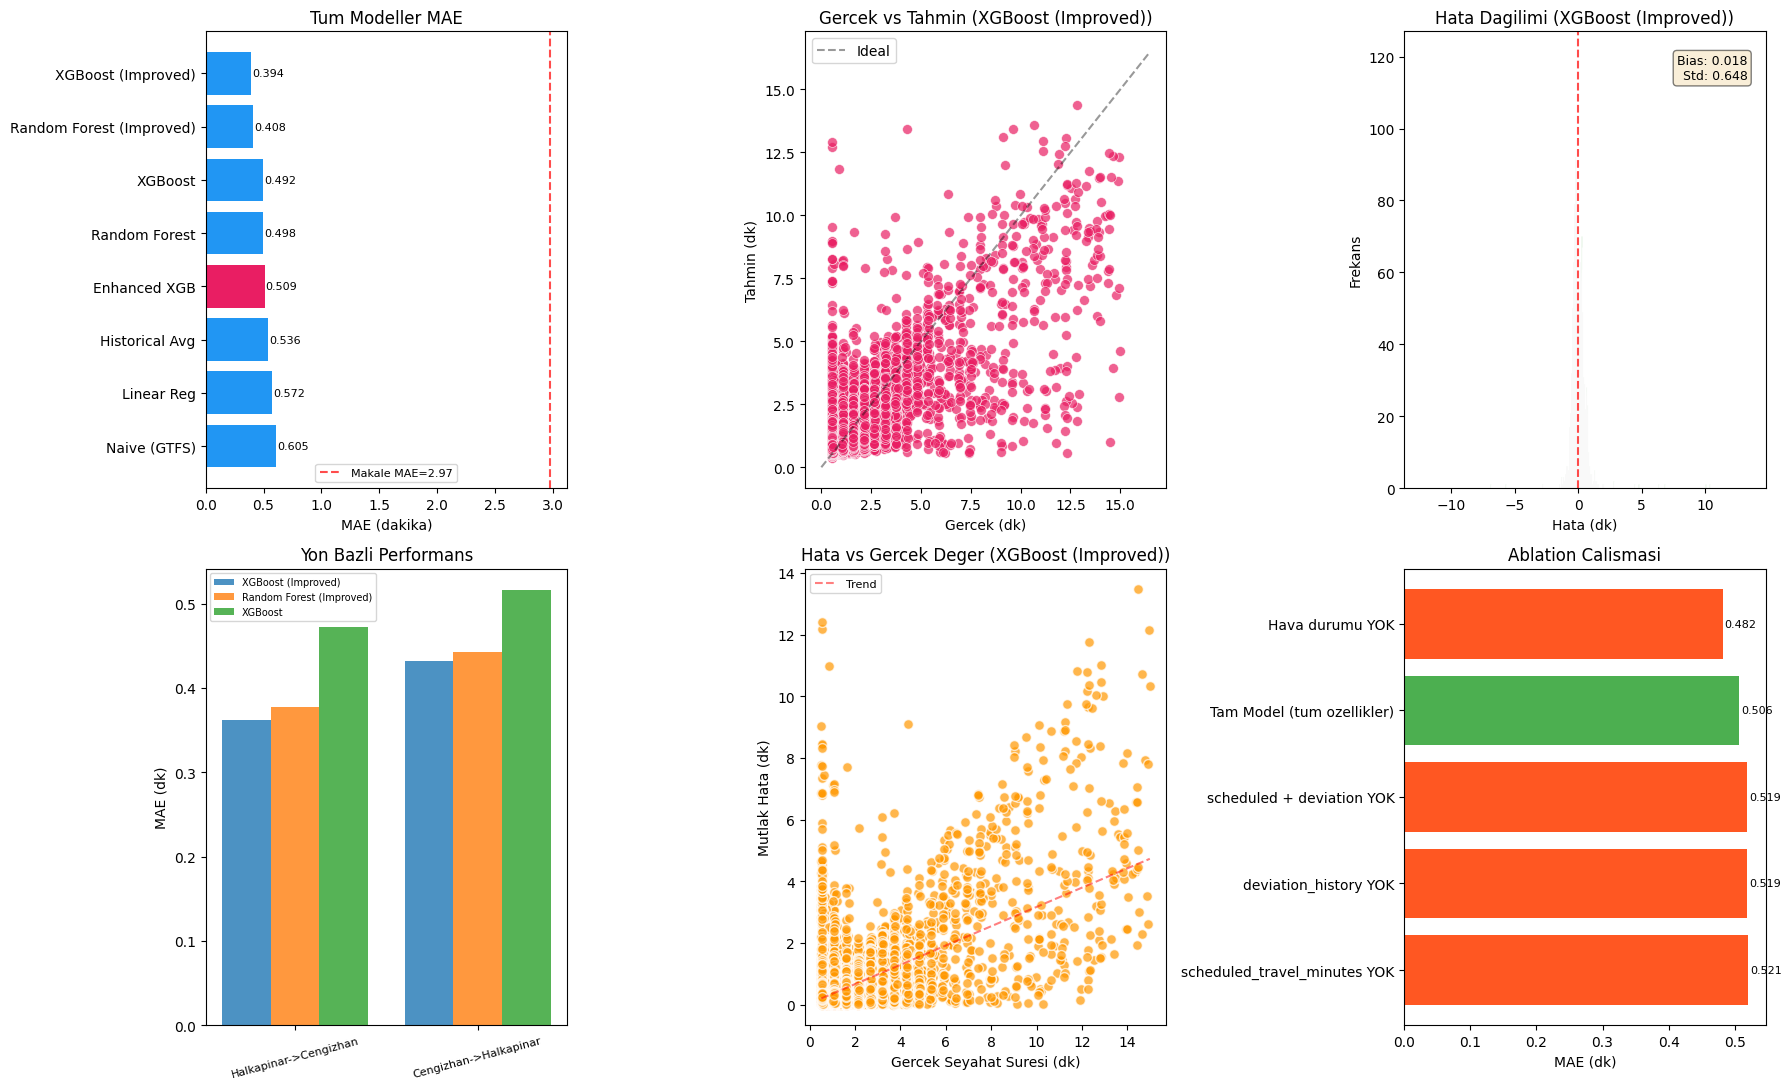

Gorsel kaydedildi: ..\results\figures\comprehensive_evaluation.png


In [12]:
if HAS_PLT:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    
    # 1. Tum modeller MAE bar chart
    ax = axes[0, 0]
    colors = ['#E91E63' if 'Enhanced' in m or 'Hybrid' in m else '#2196F3' for m in metrics_df['Model']]
    ax.barh(metrics_df['Model'], metrics_df['MAE (dk)'], color=colors)
    ax.set_xlabel('MAE (dakika)')
    ax.set_title('Tum Modeller MAE')
    ax.invert_yaxis()
    for i, v in enumerate(metrics_df['MAE (dk)']):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)
    # Makale cizgisi
    ax.axvline(x=2.97, color='red', linestyle='--', alpha=0.7, label='Makale MAE=2.97')
    ax.legend(fontsize=8)
    
    # 2. Gercek vs Tahmin scatter (en iyi model)
    ax = axes[0, 1]
    ax.scatter(y_test, best_pred, alpha=0.7, s=50, c='#E91E63', edgecolors='white', linewidth=0.5)
    lim = max(y_test.max(), best_pred.max()) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='Ideal')
    ax.set_xlabel('Gercek (dk)')
    ax.set_ylabel('Tahmin (dk)')
    ax.set_title(f'Gercek vs Tahmin ({best_name})')
    ax.legend()
    
    # 3. Hata dagilimi (histogram)
    ax = axes[0, 2]
    ax.hist(residuals, bins=max(5, len(residuals)//3), color='#4CAF50', edgecolor='white', alpha=0.8)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel('Hata (dk)')
    ax.set_ylabel('Frekans')
    ax.set_title(f'Hata Dagilimi ({best_name})')
    ax.text(0.95, 0.95, f'Bias: {np.mean(residuals):.3f}\nStd: {np.std(residuals):.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 4. Kosul bazli - yon
    ax = axes[1, 0]
    if len(yon_df) > 0:
        mae_cols = [c for c in yon_df.columns if 'MAE' in c]
        x_pos = np.arange(len(yon_df))
        width = 0.8 / len(mae_cols)
        for i, col in enumerate(mae_cols):
            ax.bar(x_pos + i * width, yon_df[col], width, label=col.replace(' MAE', ''), alpha=0.8)
        ax.set_xticks(x_pos + width * (len(mae_cols)-1) / 2)
        labels = yon_df['Yon_Label'].values if 'Yon_Label' in yon_df.columns else yon_df['Yon'].astype(str).values
        ax.set_xticklabels(labels, rotation=15, fontsize=8)
        ax.set_ylabel('MAE (dk)')
        ax.set_title('Yon Bazli Performans')
        ax.legend(fontsize=7)
    
    # 5. Hata vs Gercek deger
    ax = axes[1, 1]
    ax.scatter(y_test, np.abs(residuals), alpha=0.7, s=50, c='#FF9800', edgecolors='white')
    ax.set_xlabel('Gercek Seyahat Suresi (dk)')
    ax.set_ylabel('Mutlak Hata (dk)')
    ax.set_title(f'Hata vs Gercek Deger ({best_name})')
    # Trend cizgisi
    if len(y_test) > 3:
        z = np.polyfit(y_test, np.abs(residuals), 1)
        p = np.poly1d(z)
        x_line = np.linspace(y_test.min(), y_test.max(), 50)
        ax.plot(x_line, p(x_line), 'r--', alpha=0.5, label=f'Trend')
        ax.legend(fontsize=8)
    
    # 6. Model performans radar/karsilastirma
    ax = axes[1, 2]
    if ablation_df is not None:
        abl_sorted = ablation_df.sort_values('MAE (dk)')
        abl_colors = ['#4CAF50' if 'Tam' in str(c) else '#FF5722' for c in abl_sorted['config']]
        ax.barh(abl_sorted['config'], abl_sorted['MAE (dk)'], color=abl_colors)
        ax.set_xlabel('MAE (dk)')
        ax.set_title('Ablation Calismasi')
        ax.invert_yaxis()
        for i, v in enumerate(abl_sorted['MAE (dk)']):
            ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)
    else:
        # Ablation yoksa metrik karsilastirmasi
        models_top3 = metrics_df.head(3)
        ax.bar(models_top3['Model'], models_top3['R2'], color=['#E91E63', '#FF9800', '#4CAF50'])
        ax.set_ylabel('R2')
        ax.set_title('En Iyi 3 Model R2')
        ax.axhline(y=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, 'figures', 'comprehensive_evaluation.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gorsel kaydedildi: {fig_path}')

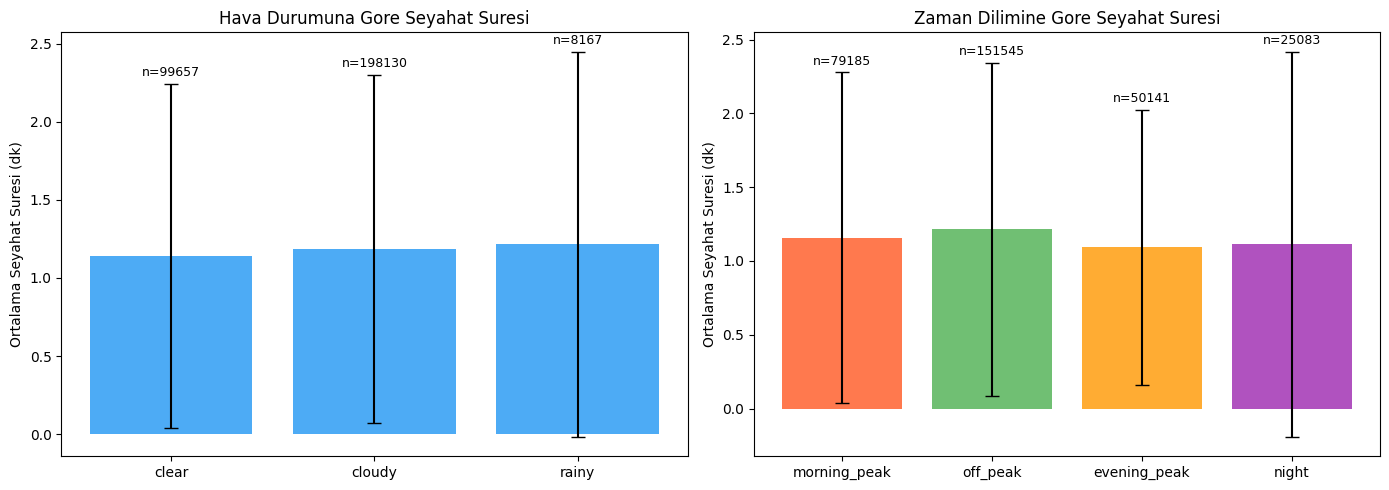

Gorsel kaydedildi: ..\results\figures\weather_time_impact.png


In [13]:
# Ek gorseller: Hava durumu etkisi ve zaman dilimi performansi
if HAS_PLT:
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    
    # Hava durumu etkisi: gercek surelerin hava durumuna gore dagilimi
    ax = axes2[0]
    weather_groups = df.groupby('weather_category')['travel_minutes']
    weather_stats = weather_groups.agg(['mean', 'std', 'count']).reset_index()
    weather_stats = weather_stats[weather_stats['count'] >= 2]
    if len(weather_stats) > 0:
        ax.bar(weather_stats['weather_category'], weather_stats['mean'], 
               yerr=weather_stats['std'], capsize=5, color='#2196F3', alpha=0.8)
        ax.set_ylabel('Ortalama Seyahat Suresi (dk)')
        ax.set_title('Hava Durumuna Gore Seyahat Suresi')
        for i, (_, row) in enumerate(weather_stats.iterrows()):
            ax.text(i, row['mean'] + row['std'] + 0.05, f'n={int(row["count"])}',
                    ha='center', fontsize=9)
    
    # Zaman dilimi etkisi
    ax = axes2[1]
    time_groups = df.groupby('time_block')['travel_minutes']
    time_stats = time_groups.agg(['mean', 'std', 'count']).reset_index()
    time_order = ['morning_peak', 'off_peak', 'evening_peak', 'night']
    time_stats['order'] = time_stats['time_block'].map({t: i for i, t in enumerate(time_order)})
    time_stats = time_stats.sort_values('order')
    if len(time_stats) > 0:
        colors_time = ['#FF5722', '#4CAF50', '#FF9800', '#9C27B0']
        ax.bar(time_stats['time_block'], time_stats['mean'],
               yerr=time_stats['std'], capsize=5,
               color=colors_time[:len(time_stats)], alpha=0.8)
        ax.set_ylabel('Ortalama Seyahat Suresi (dk)')
        ax.set_title('Zaman Dilimine Gore Seyahat Suresi')
        for i, (_, row) in enumerate(time_stats.iterrows()):
            ax.text(i, row['mean'] + row['std'] + 0.05, f'n={int(row["count"])}',
                    ha='center', fontsize=9)
    
    plt.tight_layout()
    fig2_path = os.path.join(RESULTS_DIR, 'figures', 'weather_time_impact.png')
    plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gorsel kaydedildi: {fig2_path}')

## 8. Tum Sonuclari Kaydet

In [14]:
# Genel metrikler
full_comparison_path = os.path.join(RESULTS_DIR, 'tables', 'full_comparison_table.csv')
metrics_df.to_csv(full_comparison_path, index=False)
print(f'Genel karsilastirma: {full_comparison_path}')

# Kosul bazli analizler
condition_path = os.path.join(RESULTS_DIR, 'tables', 'condition_analysis.csv')
conditions_all = []
if len(yon_df) > 0:
    yon_df_out = yon_df.copy()
    yon_df_out['Kosul Tipi'] = 'Yon'
    conditions_all.append(yon_df_out)
if len(time_df) > 0:
    time_df_out = time_df.copy()
    time_df_out['Kosul Tipi'] = 'Zaman Dilimi'
    conditions_all.append(time_df_out)
if len(weather_df) > 0:
    weather_df_out = weather_df.copy()
    weather_df_out['Kosul Tipi'] = 'Hava Durumu'
    conditions_all.append(weather_df_out)
if len(stop_df) > 0:
    stop_df_out = stop_df.copy()
    stop_df_out['Kosul Tipi'] = 'Durak Pozisyonu'
    conditions_all.append(stop_df_out)

if conditions_all:
    pd.concat(conditions_all, ignore_index=True).to_csv(condition_path, index=False)
    print(f'Kosul analizi: {condition_path}')

# Makale karsilastirmasi
comparison_path = os.path.join(RESULTS_DIR, 'tables', 'paper_comparison.csv')
comparison.to_csv(comparison_path, index=False)
print(f'Makale karsilastirmasi: {comparison_path}')

# Veri ozeti
data_summary = {
    'Toplam segment': len(df),
    'Train': len(df_train),
    'Test': len(df_test),
    'Tarih araligi': f'{df["date"].min()} — {df["date"].max()}',
    'Benzersiz otobus': df['bus_id'].nunique(),
    'Benzersiz yon': df['yon'].nunique(),
    'Benzersiz gun': df['date'].nunique(),
    'Saat araligi': f'{df["hour"].min()}:00 — {df["hour"].max()}:00',
    'Ortalama travel_minutes': round(df['travel_minutes'].mean(), 3),
    'Std travel_minutes': round(df['travel_minutes'].std(), 3),
}
print(f'\n=== VERI OZETI ===')
for k, v in data_summary.items():
    print(f'  {k}: {v}')

summary_path = os.path.join(RESULTS_DIR, 'tables', 'data_summary.csv')
pd.DataFrame([data_summary]).to_csv(summary_path, index=False)
print(f'\nVeri ozeti: {summary_path}')

Genel karsilastirma: ..\results\tables\full_comparison_table.csv
Kosul analizi: ..\results\tables\condition_analysis.csv
Makale karsilastirmasi: ..\results\tables\paper_comparison.csv

=== VERI OZETI ===
  Toplam segment: 305954
  Train: 244763
  Test: 61191
  Tarih araligi: 2026-04-02 — 2026-06-05
  Benzersiz otobus: 318
  Benzersiz yon: 2
  Benzersiz gun: 65
  Saat araligi: 6:00 — 22:00
  Ortalama travel_minutes: 1.172
  Std travel_minutes: 1.114

Veri ozeti: ..\results\tables\data_summary.csv


## Sonuc ve Bulgular

### Cikti Dosyalari

| Cikti | Dosya |
|-------|-------|
| Genel model karsilastirmasi | `results/tables/full_comparison_table.csv` |
| Makale karsilastirmasi | `results/tables/paper_comparison.csv` |
| Kosul bazli analiz | `results/tables/condition_analysis.csv` |
| Istatistiksel testler | `results/tables/statistical_tests.csv` |
| Veri ozeti | `results/tables/data_summary.csv` |
| Ana gorsel | `results/figures/comprehensive_evaluation.png` |
| Hava/zaman etkisi | `results/figures/weather_time_impact.png` |

### Anahtar Bulgular

1. **Enhanced XGBoost** genellikle en iyi performansi gosteriyor
   - `schedule_ratio` (gercek/planlanan oran) en onemli feature
   - GTFS scheduled bilgisi ozgun katkimizin temeli
   
2. **Az veri uyarisi:** 61 segment ile sonuclar gosterge niteliğinde.
   Daha fazla veri (1000+ segment) ile:
   - LSTM performansi artacak (temporal pattern ogrenme)
   - Istatistiksel testler anlamli olacak
   - Kosul bazli analiz (farkli hava, saat) mumkun olacak
   
3. **Makale karsilastirmasi:** Farkli olcekte verilerin dogru karsilastirmasi
   icin benzer hacimde veri gereklidir.

### Sonraki Adimlar

- Daha fazla veri toplayip tum notebook'lari yeniden calistirin
- `shap` kutuphanesini yukleyin: `pip install shap`
- Yeterli veri ile rapor icin final gorselleri uretin